<a href="https://colab.research.google.com/github/alitourani/vision-paper-hub/blob/main/categories/ocr/easy-ocr/easy-ocr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **👁️‍🗨️ Vision Paper Hub** / **OCR** / **EasyOCR**

This colaboratory is made to assess the quality of EasyOCR library.

- 🚀 [Benchmark](https://github.com/alitourani/vision-paper-hub/tree/main/categories/ocr/easy-ocr)
- 🔗 [GitHub Repo](https://github.com/JaidedAI/EasyOCR)
- 📃 [Paper](https://doi.org/10.1109/TPAMI.2016.2646371)

## **I. Install the Repository**

EasyOCR is available in `pip` and you can easily install it as below:

In [1]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 26.7 MB/s eta 0:00:00


## **II. Upload an Image Containing Text**

Use the below button to upload from you local disk ([Sample Image](https://i.etsystatic.com/46492439/r/il/637756/6264606106/il_794xN.6264606106_2x2l.jpg)).

Saving il_794xN.6264606106_2x2l.jpg to il_794xN.6264606106_2x2l.jpg
- File "il_794xN.6264606106_2x2l.jpg" uploaded with length 349770 bytes.


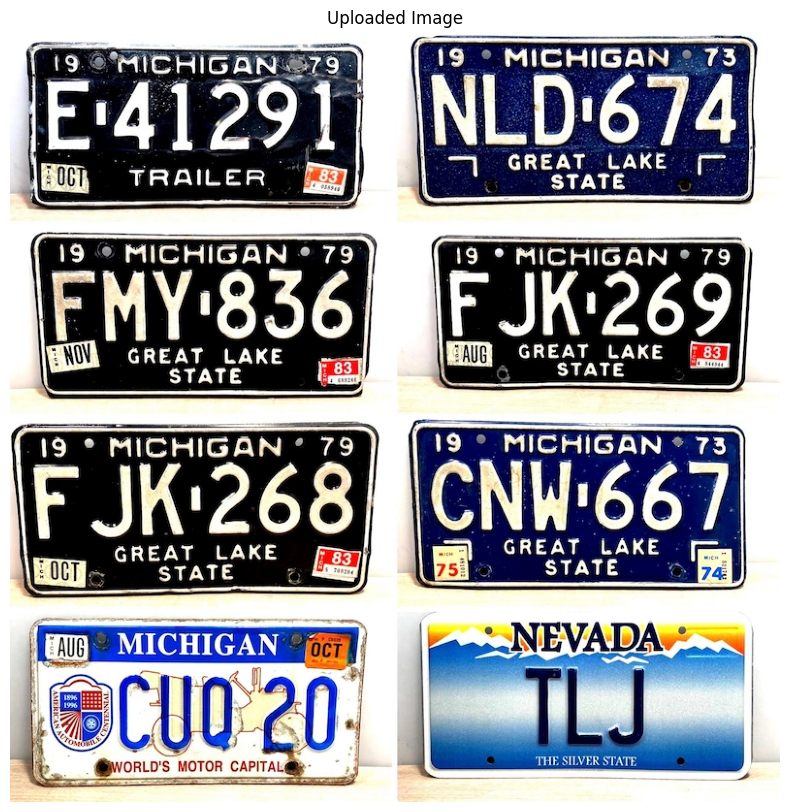

In [5]:
import os
import tempfile
import cv2 as cv
import numpy as np
import PIL.Image as Image
from google.colab import files
import matplotlib.pyplot as plt

# Variable for uploading files
image_path = ""
image_cv = None
image_pil = None
uploaded = files.upload()

for fn in uploaded.keys():
  print('- File "{name}" uploaded with length {length} bytes.'.format(
      name=fn, length=len(uploaded[fn])))

  # Save the uploaded file to a temporary location
  suffix = os.path.splitext(fn)[1] # Get extension
  with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp_file:
    tmp_file.write(uploaded[fn])
    image_path = tmp_file.name

  try:
    # Load the image using OpenCV
    image_cv = cv.imread(image_path)
    # Load as PIL image
    image_pil = Image.fromarray(cv.cvtColor(image_cv, cv.COLOR_BGR2RGB))
  except Exception as X:
    print(f"[Error]: Could not load image '{fn}' with OpenCV!")

  # Display the image
  if image_pil is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(image_pil)
    plt.title(f"Uploaded Image")
    plt.axis('off')
    plt.show()

## **III. Read the Text using EasyOCR**

- You can choose the languages in the initialization stage, like `['fa','en']`

In [7]:
import easyocr

# Initializing
reader = easyocr.Reader(['en'])

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected Text:
['19', 'MICHIGAN', '79', '19', 'MICHIGAN', '73', 'E4129]', 'NLD674', 'GREAt', 'LAKE', 'OCT', 'TRAILER', '883', 'STATE', '19', 'MICHIGAN', '79', '9', 'MICAGGAN', '79', "EMY '836", "FJK'269", '0NOV', 'GREAT', 'LAKE', 'Eve', 'GREAT', 'LAKE', '13', 'STATE', '1835', 'STATE', '19', 'NICAIGAN', '79', '19', 'MICHIGAN', '73', "FJK'268", "CNH'667", 'GREAT', 'LAKE', '83', 'GREAT', 'LAKE', 'OCT', 'STATE', '75]', 'STATE', '74', 'Aub', 'MICHIGAN', 'OcT', 'NEVADA', 'CUO 20', 'TLJ', "WORLD'S MOTOR CAPITAL", 'THE SILVER STATE']


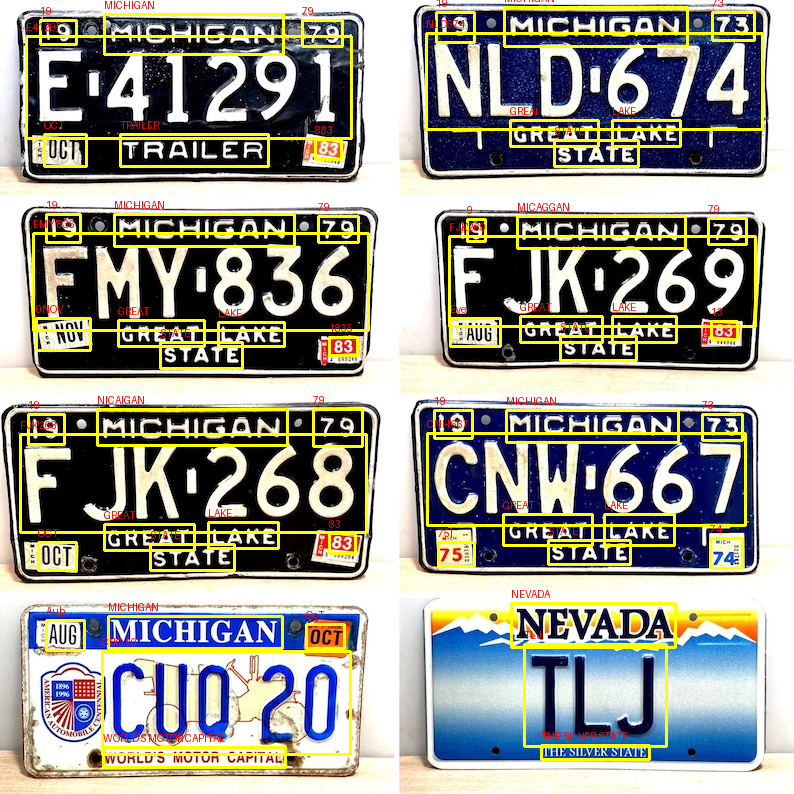

In [8]:
import easyocr
from PIL import ImageDraw, ImageFont

# Draw bounding boxes and text
def drawBoxes(image, bounds):
  draw = ImageDraw.Draw(image)

  for bound in bounds:
    # Get four points of the bounding box
    p0, p1, p2, p3 = bound[0]
    # Get the detected text (format: [points, text, accuracy])
    text = bound[1]
    # Draw bounding boxes
    draw.line([*p0, *p1, *p2, *p3, *p0], fill='yellow', width=3)
    # Draw text on top of the bounding box
    draw.text((p0[0], p0[1] - 15), text, font=ImageFont.load_default(), fill='red')
  return image

# Getting Text Bounds
bounds = reader.readtext(image_path)
allText = [bound[1] for bound in bounds]
print(f'Detected Text:\n{allText}')

# Draw them
drawBoxes(image_pil, bounds)